In [1]:
#加载各类需要用到的程序包
import os
import pywt
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签SimHei
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
from pandas import DataFrame
from pandas import concat#相空间重构用到的包
import seaborn as sns
from scipy.stats import pearsonr
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
from PyEMD import CEEMDAN
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 按「风电场1/2/3 行，相关系数/互信息/特征重要性 列」排列
img_paths = [
    "风电场1相关系数.png", "风电场1互信息.png", "风电场1特征重要性.png",
    "风电场2相关系数.png", "风电场2互信息.png", "风电场2特征重要性.png",
    "风电场3相关系数.png", "风电场3互信息.png", "风电场3特征重要性.png"
]

# 创建 3×3 子图，设置足够大的画布以匹配热力图高度
fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=500)
axes = axes.flatten()

for i, (ax, path) in enumerate(zip(axes, img_paths)):
    img = mpimg.imread(path)
    # 以热力图高度为基准，强制所有子图的显示区域比例一致
    ax.imshow(img, aspect='auto')
    ax.axis('off')

# 关键：通过 wspace/hspace 控制间距，同时让行高统一
plt.subplots_adjust(wspace=0.03, hspace=0.15, top=0.95, bottom=0.05, left=0.05, right=0.95)

plt.savefig("风电场影响因素3x3_等高总图.png", dpi=500, bbox_inches='tight')
plt.show()

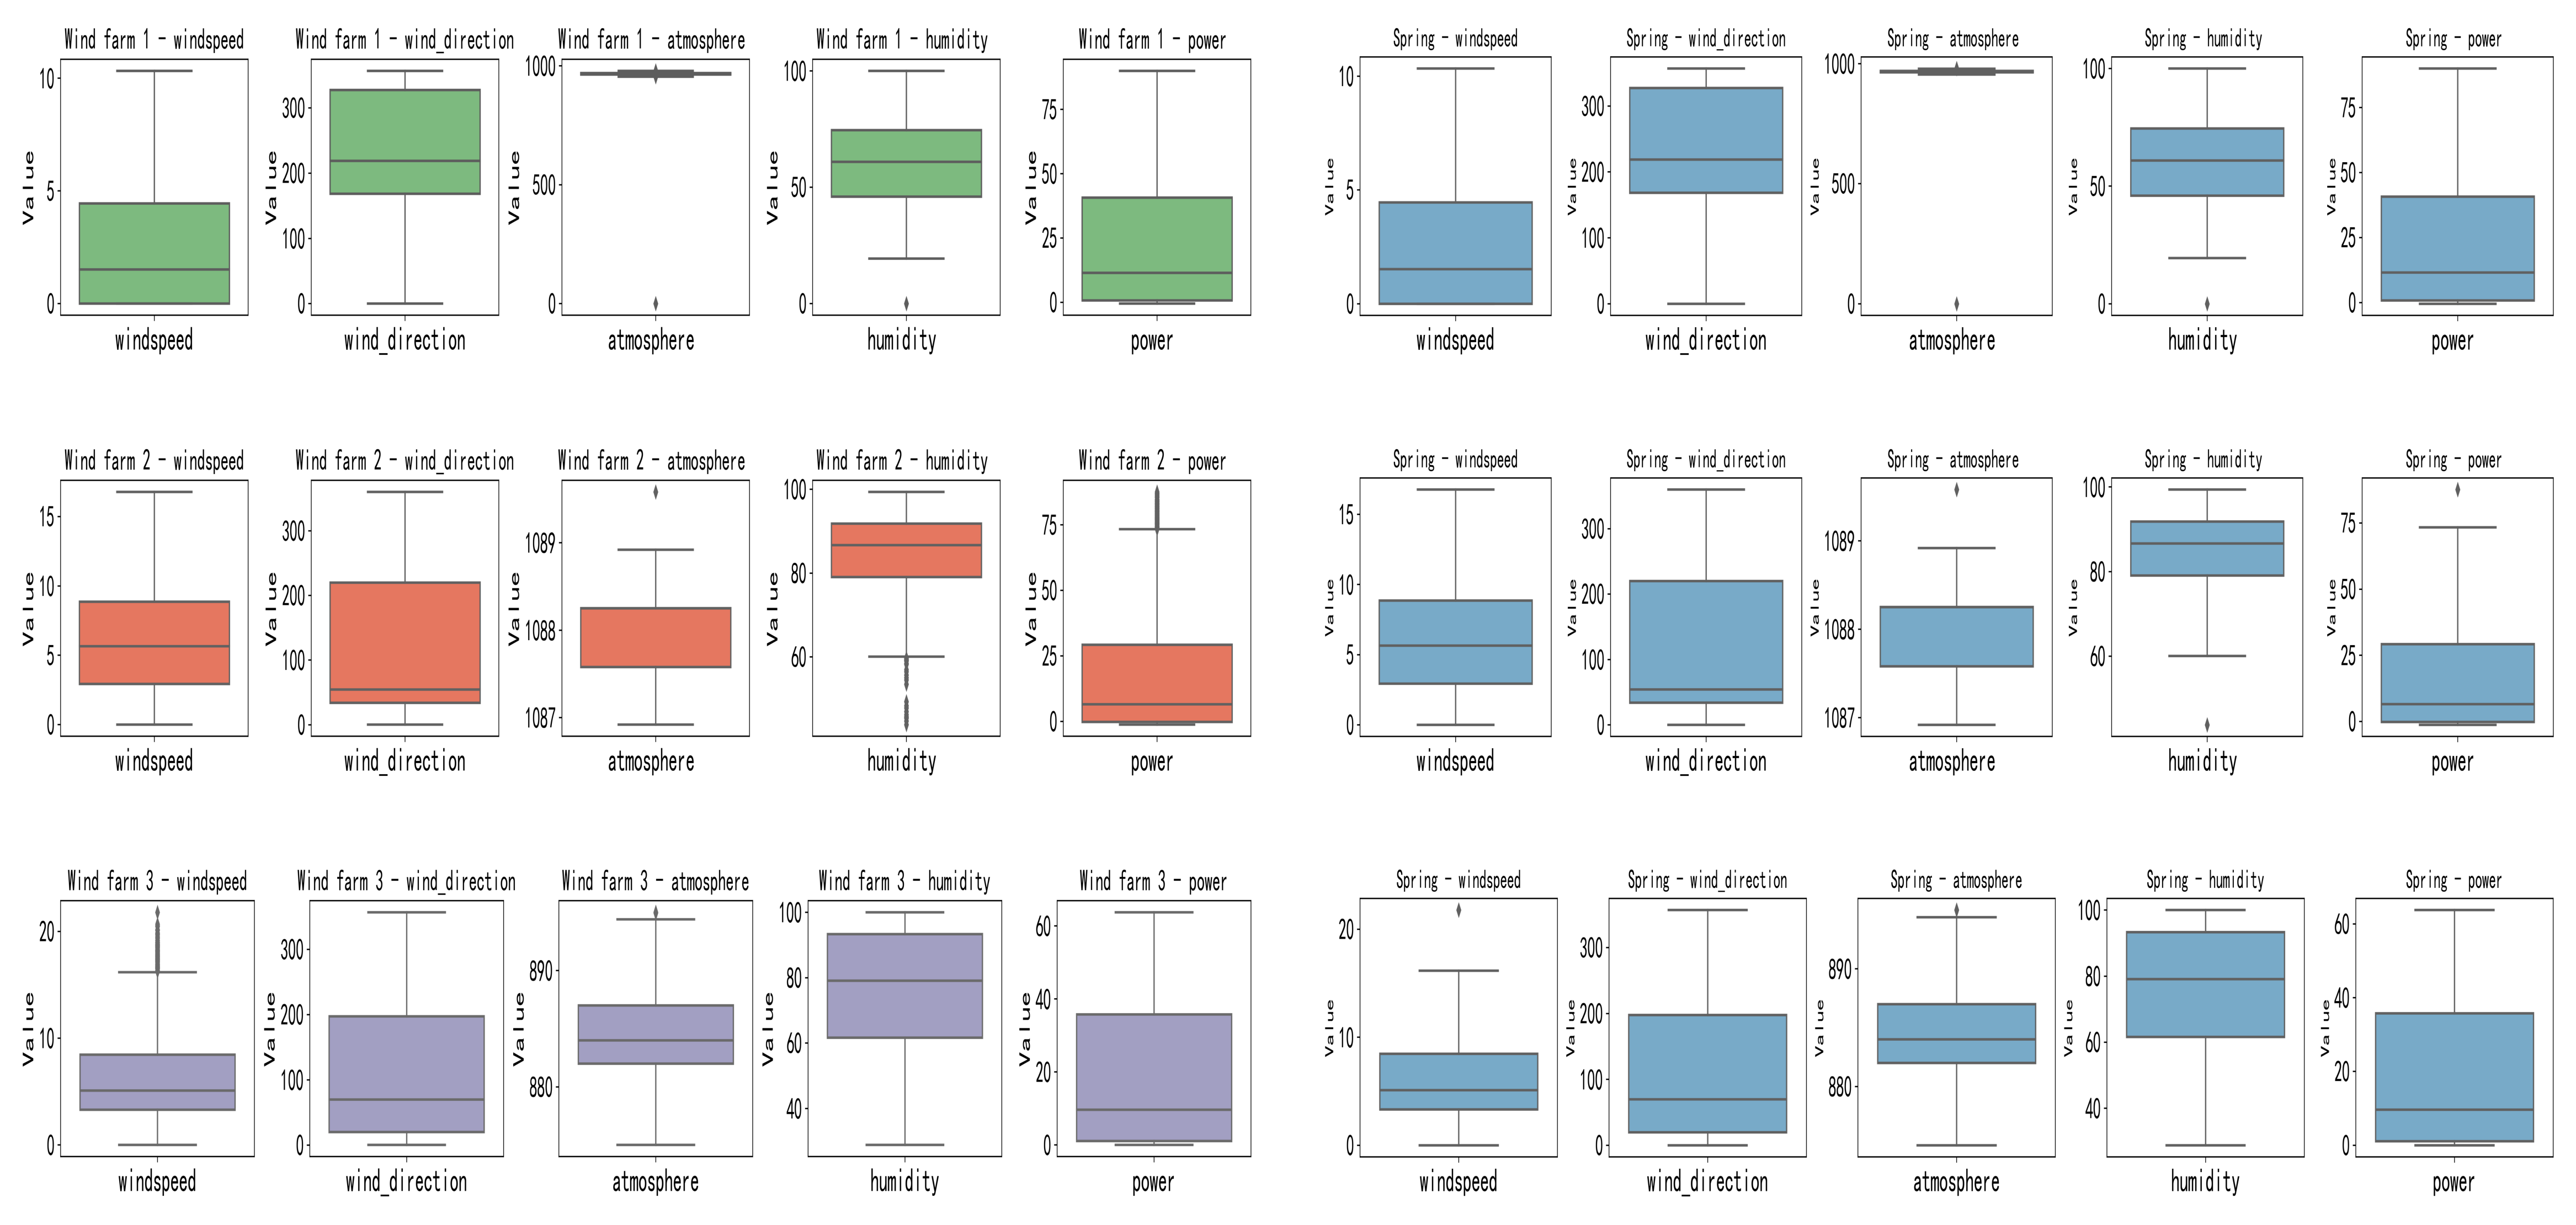

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 图片路径：左列原始箱线图，右列修正箱线图
img_paths = [
    "风电场1箱线图.png", "风电场1修正箱线图.png",
    "风电场2箱线图.png", "风电场2修正箱线图.png",
    "风电场3箱线图.png", "风电场3修正箱线图.png"
]

# 创建3行2列子图，画布尺寸调整为宽16、高8，整体高度降低，子图更矮
fig, axes = plt.subplots(3, 2, figsize=(16, 8), dpi=300)
axes = axes.flatten()

for i, (ax, path) in enumerate(zip(axes, img_paths)):
    img = mpimg.imread(path)
    # 保持子图高度一致，同时让图片自动适配子图
    ax.imshow(img, aspect='auto')
    ax.axis('off')

# 调整子图间距，避免挤压，同时保留左右对比的布局
plt.subplots_adjust(wspace=0.05, hspace=0.2, left=0.02, right=0.98, top=0.95, bottom=0.05)

# 保存高清图
plt.savefig("风电场箱线图3x2_紧凑对比总图.png", dpi=500, bbox_inches='tight')
plt.show()

In [3]:
#电力调度成本缩减
#导入文件
dispatch_data = pd.read_excel(r'D:\article\All_DMD_Predictions.xlsx', sheet_name=None)
dispatch_df = pd.concat(dispatch_data.values(), ignore_index=True)
dispatch_df

,wind_power_cost,renewable_energy_cost,coal_power_cost,storage_discharge_cost,storage_charge_cost,iTransformer_DMD1,y_pre_iTransformer1,iTransformer_Lower_Bound1,iTransformer_Upper_Bound1,LSTM_DMD1,...,GRU_Lower_Bound3,GRU_Upper_Bound3,RNN_DMD3,y_pre_rnn3,RNN_Lower_Bound3,RNN_Upper_Bound3,y_spring_test1,y_spring_test2,y_spring_test3,load
0,0.053782,0.060699,0.076495,0.003037,0.210347,79.770902,75.677200,29.862971,134.547322,79.770861,...,0.209537,12.896957,9.923421,5.090504,-4.400511,23.842852,78.106528,6.156324,8.871966,4353.886528
1,0.021940,0.024459,0.029540,0.014507,0.243904,80.374739,68.949440,30.702031,134.248468,80.437136,...,1.643586,14.021574,10.102994,6.590096,-4.064147,26.027521,78.789757,8.939160,9.029788,4284.965344
2,0.015536,0.015536,0.098318,0.012281,0.409694,84.086216,69.585251,31.074451,133.885278,84.115132,...,2.779839,15.334053,11.739074,7.457572,-0.440729,26.319647,82.493731,11.188410,10.653004,4206.121600
3,0.017652,0.059853,0.090693,0.012900,0.099487,83.070894,69.701553,32.537690,133.428576,83.106266,...,3.410069,16.256024,10.707500,7.911440,-1.793334,24.967316,81.477037,7.696126,9.614700,4154.520160
4,0.027436,0.039884,0.067455,0.011544,0.316224,82.609437,66.923439,36.718644,133.616519,82.717497,...,4.406618,17.622443,8.234728,11.443765,0.540623,24.571905,81.048365,7.020652,7.089543,4101.861280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,0.028602,0.046789,0.081994,0.019032,0.535989,12.266073,12.225561,-3.041801,59.383746,12.307748,...,0.889390,10.001908,12.133413,3.242170,-5.103598,26.616474,11.433560,53.601428,11.109858,6990.885184
551,0.045980,0.046322,0.090314,0.023124,0.299182,16.191032,13.410572,-4.040455,54.539595,16.152211,...,3.378655,13.395499,11.516426,7.473858,-1.862655,31.421349,15.344536,59.548803,10.430114,6589.038880
552,0.053142,0.068037,0.073581,0.008226,0.240339,17.622399,13.132576,-4.850466,50.065266,17.627177,...,5.552303,17.089145,12.408198,10.708942,1.492157,35.039827,16.779260,62.731328,11.273910,6495.045184
553,0.031901,0.050293,0.118162,0.023605,0.394483,16.380238,10.536007,-7.229394,41.674992,16.452289,...,5.900804,18.757873,10.036699,10.988184,0.057794,36.293832,15.567741,54.060071,8.898269,6553.640320


In [11]:
import pulp
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===================== 储能成本 =====================
storage_initial_investment = 500
storage_degradation_maintenance = 0.05 * storage_initial_investment

# ===================== iTransformer 调度 =====================
def run_itransformer_cluster(row):
    prob = pulp.LpProblem("IT_Dispatch_Cluster", pulp.LpMinimize)

    # 1. 上下界用【原始区间】
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['iTransformer_Lower_Bound1'], upBound=row['iTransformer_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['iTransformer_Lower_Bound2'], upBound=row['iTransformer_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['iTransformer_Lower_Bound3'], upBound=row['iTransformer_Upper_Bound3'], cat='Continuous')

    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    obj = (row['wind_power_cost'] * wind_power_1 +
           row['wind_power_cost'] * wind_power_2 +
           row['wind_power_cost'] * wind_power_3 +
           row['renewable_energy_cost'] * renewable_power +
           row['coal_power_cost'] * thermal_power +
           row['storage_discharge_cost'] * energy_discharge +
           row['storage_charge_cost'] * energy_charge +
           storage_degradation_maintenance)
    prob += obj

    # 2. 预测值用【DMD修正后】
    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renewable_power + thermal_power + energy_charge == row['load'] + energy_discharge
    prob += row['iTransformer_DMD1'] + row['iTransformer_DMD2'] + row['iTransformer_DMD3'] + renewable_power + thermal_power == row['load']

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind_power_1) + pulp.value(wind_power_2) + pulp.value(wind_power_3)
    return total_cost, total_wind

# ===================== DRO 版本 =====================
def run_dro_cluster(row, eps=0.05):
    prob = pulp.LpProblem("DRO_Dispatch_Cluster", pulp.LpMinimize)

    wL1 = row['iTransformer_Lower_Bound1']
    wU1 = row['iTransformer_Upper_Bound1']
    wL2 = row['iTransformer_Lower_Bound2']
    wU2 = row['iTransformer_Upper_Bound2']
    wL3 = row['iTransformer_Lower_Bound3']
    wU3 = row['iTransformer_Upper_Bound3']

    wind1 = pulp.LpVariable('WindPower_1', lowBound=wL1, upBound=wU1)
    wind2 = pulp.LpVariable('WindPower_2', lowBound=wL2, upBound=wU2)
    wind3 = pulp.LpVariable('WindPower_3', lowBound=wL3, upBound=wU3)

    renew = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5)
    thermal = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5)
    discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    charge = pulp.LpVariable('EnergyCharge', 0, 100)

    lam = pulp.LpVariable('lambda', lowBound=0)
    tau = pulp.LpVariable('tau', lowBound=0)

    prob += (
        row['wind_power_cost'] * wind1 +
        row['wind_power_cost'] * wind2 +
        row['wind_power_cost'] * wind3 +
        row['renewable_energy_cost'] * renew +
        row['coal_power_cost'] * thermal +
        row['storage_discharge_cost'] * discharge +
        row['storage_charge_cost'] * charge +
        storage_degradation_maintenance +
        eps * lam
    )

    # 预测值同样用 DMD
    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renew + thermal + charge == row['load'] + discharge
    prob += row['iTransformer_DMD1'] + row['iTransformer_DMD2'] + row['iTransformer_DMD3'] + renew + thermal == row['load']

    # DRO 鲁棒约束
    prob += tau >= (wU1 - wind1) * row['coal_power_cost']
    prob += tau >= (wind1 - wL1) * row['coal_power_cost']
    prob += tau >= (wU2 - wind2) * row['coal_power_cost']
    prob += tau >= (wind2 - wL2) * row['coal_power_cost']
    prob += tau >= (wU3 - wind3) * row['coal_power_cost']
    prob += tau >= (wind3 - wL3) * row['coal_power_cost']
    prob += lam >= tau

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind1) + pulp.value(wind2) + pulp.value(wind3)
    return total_cost, total_wind

# ===================== 运行 =====================
cost_it_list = []
cost_dro_list = []
wind_it_list = []
wind_dro_list = []

print("正在运行 iTransformer(DMD预测)+DRO 对比...\n")

for idx, row in dispatch_df.iterrows():
    cost_it, wind_it = run_itransformer_cluster(row)
    cost_dro, wind_dro = run_dro_cluster(row, eps=0.05)
    
    cost_it_list.append(cost_it)
    cost_dro_list.append(cost_dro)
    wind_it_list.append(wind_it)
    wind_dro_list.append(wind_dro)

# ===================== 输出 =====================
print("=" * 60)
print("           iTransformer 最终结果")
print("=" * 60)
print(f"iTransformer-DMD 平均成本: {np.mean(cost_it_list):.2f} $")
print(f"DRO 平均成本              : {np.mean(cost_dro_list):.2f} $")
print(f"成本降低比例              : {(np.mean(cost_dro_list)-np.mean(cost_it_list))/np.mean(cost_dro_list)*100:.2f}%")
print("-"*60)
print(f"iTransformer 平均风电: {np.mean(wind_it_list):.2f} MW")
print(f"DRO 平均风电         : {np.mean(wind_dro_list):.2f} MW")
print("="*60)

df_out = pd.DataFrame({
    "iTransformer_DMD_Cost": cost_it_list,
    "DRO_Cost": cost_dro_list,
    "iTransformer_Wind": wind_it_list,
    "DRO_Wind": wind_dro_list
})
df_out.to_excel("iTransformer_FINAL.xlsx", index=False)
print("\n结果已保存：iTransformer_FINAL.xlsx")

正在运行 iTransformer(DMD预测)+DRO 对比...

           iTransformer 最终结果
iTransformer-DMD 平均成本: 447.24 $
DRO 平均成本              : 447.55 $
成本降低比例              : 0.07%
------------------------------------------------------------
iTransformer 平均风电: 1.62 MW
DRO 平均风电         : 2.21 MW

结果已保存：iTransformer_FINAL.xlsx


In [10]:
import pulp
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

storage_initial_investment = 500
storage_degradation_maintenance = 0.05 * storage_initial_investment

# LSTM-DMD常规调度：等式预测=DMD，风电区间=原始上下界
def run_lstm_cluster(row):
    prob = pulp.LpProblem("LSTM_DMD_Cluster", pulp.LpMinimize)
    # 区间恢复原始上下限
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['LSTM_Lower_Bound1'], upBound=row['LSTM_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['LSTM_Lower_Bound2'], upBound=row['LSTM_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['LSTM_Lower_Bound3'], upBound=row['LSTM_Upper_Bound3'], cat='Continuous')

    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    obj = (row['wind_power_cost'] * wind_power_1 +
           row['wind_power_cost'] * wind_power_2 +
           row['wind_power_cost'] * wind_power_3 +
           row['renewable_energy_cost'] * renewable_power +
           row['coal_power_cost'] * thermal_power +
           row['storage_discharge_cost'] * energy_discharge +
           row['storage_charge_cost'] * energy_charge +
           storage_degradation_maintenance)
    prob += obj

    # 关键：功率平衡的预测项 = DMD修正值（不变）
    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renewable_power + thermal_power + energy_charge == row['load'] + energy_discharge
    prob += row['LSTM_DMD1'] + row['LSTM_DMD2'] + row['LSTM_DMD3'] + renewable_power + thermal_power == row['load']

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind_power_1)+pulp.value(wind_power_2)+pulp.value(wind_power_3)
    return total_cost, total_wind

# DRO模型：预测基准=DMD，鲁棒区间=原始上下限
def run_dro_cluster_lstm(row, eps=0.05):
    prob = pulp.LpProblem("DRO_Dispatch_LSTM", pulp.LpMinimize)
    wL1 = row['LSTM_Lower_Bound1']
    wU1 = row['LSTM_Upper_Bound1']
    wL2 = row['LSTM_Lower_Bound2']
    wU2 = row['LSTM_Upper_Bound2']
    wL3 = row['LSTM_Lower_Bound3']
    wU3 = row['LSTM_Upper_Bound3']

    wind1 = pulp.LpVariable('WindPower_1', lowBound=wL1, upBound=wU1)
    wind2 = pulp.LpVariable('WindPower_2', lowBound=wL2, upBound=wU2)
    wind3 = pulp.LpVariable('WindPower_3', lowBound=wL3, upBound=wU3)

    renew = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load']*0.5)
    thermal = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load']*0.5)
    discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    charge = pulp.LpVariable('EnergyCharge', 0, 100)

    lam = pulp.LpVariable('lambda', lowBound=0)
    tau = pulp.LpVariable('tau', lowBound=0)

    prob += (
        row['wind_power_cost'] * wind1 +
        row['wind_power_cost'] * wind2 +
        row['wind_power_cost'] * wind3 +
        row['renewable_energy_cost'] * renew +
        row['coal_power_cost'] * thermal +
        row['storage_discharge_cost'] * discharge +
        row['storage_charge_cost'] * charge +
        storage_degradation_maintenance + eps*lam
    )

    # 等式约束依旧DMD
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3']+renew+thermal+charge == row['load']+discharge
    prob += row['LSTM_DMD1']+row['LSTM_DMD2']+row['LSTM_DMD3']+renew+thermal == row['load']

    # DRO鲁棒约束基于原始区间
    prob += tau >= (wU1 - wind1)*row['coal_power_cost']
    prob += tau >= (wind1 - wL1)*row['coal_power_cost']
    prob += tau >= (wU2 - wind2)*row['coal_power_cost']
    prob += tau >= (wind2 - wL2)*row['coal_power_cost']
    prob += tau >= (wU3 - wind3)*row['coal_power_cost']
    prob += tau >= (wind3 - wL3)*row['coal_power_cost']
    prob += lam >= tau

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind1)+pulp.value(wind2)+pulp.value(wind3)
    return total_cost, total_wind

cost_lstm_list = []
cost_dro_list = []
wind_lstm_list = []
wind_dro_list = []

print("正在运行 LSTM(DMD基准+原始波动区间)+DRO\n")
for idx,row in dispatch_df.iterrows():
    c1,w1 = run_lstm_cluster(row)
    c2,w2 = run_dro_cluster_lstm(row,eps=0.05)
    cost_lstm_list.append(c1)
    cost_dro_list.append(c2)
    wind_lstm_list.append(w1)
    wind_dro_list.append(w2)

print("="*60)
print(f"LSTM-DMD平均成本:{np.mean(cost_lstm_list):.2f} $")
print(f"DRO平均成本:     {np.mean(cost_dro_list):.2f} $")
save_rate = (np.mean(cost_dro_list)-np.mean(cost_lstm_list))/np.mean(cost_dro_list)*100
print(f"成本节约率:      {save_rate:.2f} %")
print(f"LSTM平均风电:{np.mean(wind_lstm_list):.2f} MW")
print(f"DRO平均风电: {np.mean(wind_dro_list):.2f} MW")
print("="*60)

pd.DataFrame({
    "LSTM_DMD_Cost":cost_lstm_list,
    "DRO_Cost":cost_dro_list,
    "LSTM_Wind":wind_lstm_list,
    "DRO_Wind":wind_dro_list
}).to_excel("LSTM_Fixed_DMD.xlsx",index=False)

正在运行 LSTM(DMD基准+原始波动区间)+DRO

LSTM-DMD平均成本:448.28 $
DRO平均成本:     448.45 $
成本节约率:      0.04 %
LSTM平均风电:32.88 MW
DRO平均风电: 33.16 MW


In [12]:
import pulp
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===================== 储能成本 =====================
storage_initial_investment = 500
storage_degradation_maintenance = 0.05 * storage_initial_investment

# ===================== TCN-DMD 调度 =====================
def run_tcn_cluster(row):
    prob = pulp.LpProblem("TCN_Dispatch_Cluster", pulp.LpMinimize)

    # 上下界 = 原始区间
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['TCN_Lower_Bound1'], upBound=row['TCN_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['TCN_Lower_Bound2'], upBound=row['TCN_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['TCN_Lower_Bound3'], upBound=row['TCN_Upper_Bound3'], cat='Continuous')

    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    obj = (row['wind_power_cost'] * wind_power_1 +
           row['wind_power_cost'] * wind_power_2 +
           row['wind_power_cost'] * wind_power_3 +
           row['renewable_energy_cost'] * renewable_power +
           row['coal_power_cost'] * thermal_power +
           row['storage_discharge_cost'] * energy_discharge +
           row['storage_charge_cost'] * energy_charge +
           storage_degradation_maintenance)
    prob += obj

    # 预测值 = DMD 修正后
    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renewable_power + thermal_power + energy_charge == row['load'] + energy_discharge
    prob += row['TCN_DMD1'] + row['TCN_DMD2'] + row['TCN_DMD3'] + renewable_power + thermal_power == row['load']

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind_power_1) + pulp.value(wind_power_2) + pulp.value(wind_power_3)
    return total_cost, total_wind

# ===================== DRO 版本 =====================
def run_dro_cluster_tcn(row, eps=0.05):
    prob = pulp.LpProblem("DRO_Dispatch_TCN", pulp.LpMinimize)

    wL1 = row['TCN_Lower_Bound1']
    wU1 = row['TCN_Upper_Bound1']
    wL2 = row['TCN_Lower_Bound2']
    wU2 = row['TCN_Upper_Bound2']
    wL3 = row['TCN_Lower_Bound3']
    wU3 = row['TCN_Upper_Bound3']

    wind1 = pulp.LpVariable('WindPower_1', lowBound=wL1, upBound=wU1)
    wind2 = pulp.LpVariable('WindPower_2', lowBound=wL2, upBound=wU2)
    wind3 = pulp.LpVariable('WindPower_3', lowBound=wL3, upBound=wU3)

    renew = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5)
    thermal = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5)
    discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    charge = pulp.LpVariable('EnergyCharge', 0, 100)

    lam = pulp.LpVariable('lambda', lowBound=0)
    tau = pulp.LpVariable('tau', lowBound=0)

    prob += (
        row['wind_power_cost'] * wind1 +
        row['wind_power_cost'] * wind2 +
        row['wind_power_cost'] * wind3 +
        row['renewable_energy_cost'] * renew +
        row['coal_power_cost'] * thermal +
        row['storage_discharge_cost'] * discharge +
        row['storage_charge_cost'] * charge +
        storage_degradation_maintenance +
        eps * lam
    )

    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renew + thermal + charge == row['load'] + discharge
    prob += row['TCN_DMD1'] + row['TCN_DMD2'] + row['TCN_DMD3'] + renew + thermal == row['load']

    prob += tau >= (wU1 - wind1) * row['coal_power_cost']
    prob += tau >= (wind1 - wL1) * row['coal_power_cost']
    prob += tau >= (wU2 - wind2) * row['coal_power_cost']
    prob += tau >= (wind2 - wL2) * row['coal_power_cost']
    prob += tau >= (wU3 - wind3) * row['coal_power_cost']
    prob += tau >= (wind3 - wL3) * row['coal_power_cost']
    prob += lam >= tau

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind1) + pulp.value(wind2) + pulp.value(wind3)
    return total_cost, total_wind

# ===================== 运行 =====================
cost_tcn_list = []
cost_dro_list = []
wind_tcn_list = []
wind_dro_list = []

print("正在运行 TCN(DMD预测)+DRO 对比...\n")

for idx, row in dispatch_df.iterrows():
    cost_tcn, wind_tcn = run_tcn_cluster(row)
    cost_dro, wind_dro = run_dro_cluster_tcn(row, eps=0.05)
    
    cost_tcn_list.append(cost_tcn)
    cost_dro_list.append(cost_dro)
    wind_tcn_list.append(wind_tcn)
    wind_dro_list.append(wind_dro)

# ===================== 输出 =====================
print("=" * 60)
print("           TCN 最终结果")
print("=" * 60)
print(f"TCN-DMD 平均成本: {np.mean(cost_tcn_list):.2f} $")
print(f"DRO 平均成本:     {np.mean(cost_dro_list):.2f} $")
print(f"成本降低比例:     {(np.mean(cost_dro_list)-np.mean(cost_tcn_list))/np.mean(cost_dro_list)*100:.2f}%")
print("-"*60)
print(f"TCN 平均风电: {np.mean(wind_tcn_list):.2f} MW")
print(f"DRO 平均风电: {np.mean(wind_dro_list):.2f} MW")
print("="*60)

df_out = pd.DataFrame({
    "TCN_DMD_Cost": cost_tcn_list,
    "DRO_Cost": cost_dro_list,
    "TCN_Wind": wind_tcn_list,
    "DRO_Wind": wind_dro_list
})
df_out.to_excel("TCN_FINAL.xlsx", index=False)
print("\n结果已保存：TCN_FINAL.xlsx")

正在运行 TCN(DMD预测)+DRO 对比...

           TCN 最终结果
TCN-DMD 平均成本: 447.99 $
DRO 平均成本:     448.19 $
成本降低比例:     0.04%
------------------------------------------------------------
TCN 平均风电: 24.25 MW
DRO 平均风电: 24.63 MW

结果已保存：TCN_FINAL.xlsx


In [13]:
import pulp
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===================== 储能成本 =====================
storage_initial_investment = 500
storage_degradation_maintenance = 0.05 * storage_initial_investment

# ===================== GRU-DMD 调度 =====================
def run_gru_cluster(row):
    prob = pulp.LpProblem("GRU_Dispatch_Cluster", pulp.LpMinimize)

    # 上下界 = 原始区间
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['GRU_Lower_Bound1'], upBound=row['GRU_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['GRU_Lower_Bound2'], upBound=row['GRU_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['GRU_Lower_Bound3'], upBound=row['GRU_Upper_Bound3'], cat='Continuous')

    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    obj = (row['wind_power_cost'] * wind_power_1 +
           row['wind_power_cost'] * wind_power_2 +
           row['wind_power_cost'] * wind_power_3 +
           row['renewable_energy_cost'] * renewable_power +
           row['coal_power_cost'] * thermal_power +
           row['storage_discharge_cost'] * energy_discharge +
           row['storage_charge_cost'] * energy_charge +
           storage_degradation_maintenance)
    prob += obj

    # 预测值 = DMD 修正后
    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renewable_power + thermal_power + energy_charge == row['load'] + energy_discharge
    prob += row['GRU_DMD1'] + row['GRU_DMD2'] + row['GRU_DMD3'] + renewable_power + thermal_power == row['load']

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind_power_1) + pulp.value(wind_power_2) + pulp.value(wind_power_3)
    return total_cost, total_wind

# ===================== DRO 版本 =====================
def run_dro_cluster_gru(row, eps=0.05):
    prob = pulp.LpProblem("DRO_Dispatch_GRU", pulp.LpMinimize)

    wL1 = row['GRU_Lower_Bound1']
    wU1 = row['GRU_Upper_Bound1']
    wL2 = row['GRU_Lower_Bound2']
    wU2 = row['GRU_Upper_Bound2']
    wL3 = row['GRU_Lower_Bound3']
    wU3 = row['GRU_Upper_Bound3']

    wind1 = pulp.LpVariable('WindPower_1', lowBound=wL1, upBound=wU1)
    wind2 = pulp.LpVariable('WindPower_2', lowBound=wL2, upBound=wU2)
    wind3 = pulp.LpVariable('WindPower_3', lowBound=wL3, upBound=wU3)

    renew = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5)
    thermal = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5)
    discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    charge = pulp.LpVariable('EnergyCharge', 0, 100)

    lam = pulp.LpVariable('lambda', lowBound=0)
    tau = pulp.LpVariable('tau', lowBound=0)

    prob += (
        row['wind_power_cost'] * wind1 +
        row['wind_power_cost'] * wind2 +
        row['wind_power_cost'] * wind3 +
        row['renewable_energy_cost'] * renew +
        row['coal_power_cost'] * thermal +
        row['storage_discharge_cost'] * discharge +
        row['storage_charge_cost'] * charge +
        storage_degradation_maintenance +
        eps * lam
    )

    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renew + thermal + charge == row['load'] + discharge
    prob += row['GRU_DMD1'] + row['GRU_DMD2'] + row['GRU_DMD3'] + renew + thermal == row['load']

    prob += tau >= (wU1 - wind1) * row['coal_power_cost']
    prob += tau >= (wind1 - wL1) * row['coal_power_cost']
    prob += tau >= (wU2 - wind2) * row['coal_power_cost']
    prob += tau >= (wind2 - wL2) * row['coal_power_cost']
    prob += tau >= (wU3 - wind3) * row['coal_power_cost']
    prob += tau >= (wind3 - wL3) * row['coal_power_cost']
    prob += lam >= tau

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind1) + pulp.value(wind2) + pulp.value(wind3)
    return total_cost, total_wind

# ===================== 运行 =====================
cost_gru_list = []
cost_dro_list = []
wind_gru_list = []
wind_dro_list = []

print("正在运行 GRU(DMD预测)+DRO 对比...\n")

for idx, row in dispatch_df.iterrows():
    cost_gru, wind_gru = run_gru_cluster(row)
    cost_dro, wind_dro = run_dro_cluster_gru(row, eps=0.05)
    
    cost_gru_list.append(cost_gru)
    cost_dro_list.append(cost_dro)
    wind_gru_list.append(wind_gru)
    wind_dro_list.append(wind_dro)

# ===================== 输出 =====================
print("=" * 60)
print("           GRU 最终结果")
print("=" * 60)
print(f"GRU-DMD 平均成本: {np.mean(cost_gru_list):.2f} $")
print(f"DRO 平均成本:     {np.mean(cost_dro_list):.2f} $")
print(f"成本降低比例:     {(np.mean(cost_dro_list)-np.mean(cost_gru_list))/np.mean(cost_dro_list)*100:.2f}%")
print("-"*60)
print(f"GRU 平均风电: {np.mean(wind_gru_list):.2f} MW")
print(f"DRO 平均风电: {np.mean(wind_dro_list):.2f} MW")
print("="*60)

df_out = pd.DataFrame({
    "GRU_DMD_Cost": cost_gru_list,
    "DRO_Cost": cost_dro_list,
    "GRU_Wind": wind_gru_list,
    "DRO_Wind": wind_dro_list
})
df_out.to_excel("GRU_FINAL.xlsx", index=False)
print("\n结果已保存：GRU_FINAL.xlsx")

正在运行 GRU(DMD预测)+DRO 对比...

           GRU 最终结果
GRU-DMD 平均成本: 448.29 $
DRO 平均成本:     448.47 $
成本降低比例:     0.04%
------------------------------------------------------------
GRU 平均风电: 33.46 MW
DRO 平均风电: 33.75 MW

结果已保存：GRU_FINAL.xlsx


In [14]:
import pulp
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===================== 储能成本 =====================
storage_initial_investment = 500
storage_degradation_maintenance = 0.05 * storage_initial_investment

# ===================== RNN-DMD 确定性调度 =====================
def run_rnn_cluster(row):
    prob = pulp.LpProblem("RNN_Dispatch_Cluster", pulp.LpMinimize)

    # 风电上下限：原始区间
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['RNN_Lower_Bound1'], upBound=row['RNN_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['RNN_Lower_Bound2'], upBound=row['RNN_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['RNN_Lower_Bound3'], upBound=row['RNN_Upper_Bound3'], cat='Continuous')

    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    obj = (row['wind_power_cost'] * wind_power_1 +
           row['wind_power_cost'] * wind_power_2 +
           row['wind_power_cost'] * wind_power_3 +
           row['renewable_energy_cost'] * renewable_power +
           row['coal_power_cost'] * thermal_power +
           row['storage_discharge_cost'] * energy_discharge +
           row['storage_charge_cost'] * energy_charge +
           storage_degradation_maintenance)
    prob += obj

    # 功率平衡基准出力：DMD修正值
    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renewable_power + thermal_power + energy_charge == row['load'] + energy_discharge
    prob += row['RNN_DMD1'] + row['RNN_DMD2'] + row['RNN_DMD3'] + renewable_power + thermal_power == row['load']

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind_power_1) + pulp.value(wind_power_2) + pulp.value(wind_power_3)
    return total_cost, total_wind

# ===================== RNN配套DRO鲁棒调度 =====================
def run_dro_cluster_rnn(row, eps=0.05):
    prob = pulp.LpProblem("DRO_Dispatch_RNN", pulp.LpMinimize)

    wL1 = row['RNN_Lower_Bound1']
    wU1 = row['RNN_Upper_Bound1']
    wL2 = row['RNN_Lower_Bound2']
    wU2 = row['RNN_Upper_Bound2']
    wL3 = row['RNN_Lower_Bound3']
    wU3 = row['RNN_Upper_Bound3']

    wind1 = pulp.LpVariable('WindPower_1', lowBound=wL1, upBound=wU1)
    wind2 = pulp.LpVariable('WindPower_2', lowBound=wL2, upBound=wU2)
    wind3 = pulp.LpVariable('WindPower_3', lowBound=wL3, upBound=wU3)

    renew = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row['load'] * 0.5)
    thermal = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row['load'] * 0.5)
    discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    charge = pulp.LpVariable('EnergyCharge', 0, 100)

    lam = pulp.LpVariable('lambda', lowBound=0)
    tau = pulp.LpVariable('tau', lowBound=0)

    prob += (
        row['wind_power_cost'] * wind1 +
        row['wind_power_cost'] * wind2 +
        row['wind_power_cost'] * wind3 +
        row['renewable_energy_cost'] * renew +
        row['coal_power_cost'] * thermal +
        row['storage_discharge_cost'] * discharge +
        row['storage_charge_cost'] * charge +
        storage_degradation_maintenance + eps * lam
    )

    prob += row['y_spring_test1'] + row['y_spring_test2'] + row['y_spring_test3'] + renew + thermal + charge == row['load'] + discharge
    prob += row['RNN_DMD1'] + row['RNN_DMD2'] + row['RNN_DMD3'] + renew + thermal == row['load']

    # DRO鲁棒约束
    prob += tau >= (wU1 - wind1) * row['coal_power_cost']
    prob += tau >= (wind1 - wL1) * row['coal_power_cost']
    prob += tau >= (wU2 - wind2) * row['coal_power_cost']
    prob += tau >= (wind2 - wL2) * row['coal_power_cost']
    prob += tau >= (wU3 - wind3) * row['coal_power_cost']
    prob += tau >= (wind3 - wL3) * row['coal_power_cost']
    prob += lam >= tau

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    total_cost = pulp.value(prob.objective)
    total_wind = pulp.value(wind1) + pulp.value(wind2) + pulp.value(wind3)
    return total_cost, total_wind

# ===================== 批量运行 =====================
cost_rnn_list = []
cost_dro_list = []
wind_rnn_list = []
wind_dro_list = []

print("正在运行 RNN(DMD基准+原始区间)+DRO\n")
for idx, row in dispatch_df.iterrows():
    cost_rnn, wind_rnn = run_rnn_cluster(row)
    cost_dro, wind_dro = run_dro_cluster_rnn(row, eps=0.05)
    cost_rnn_list.append(cost_rnn)
    cost_dro_list.append(cost_dro)
    wind_rnn_list.append(wind_rnn)
    wind_dro_list.append(wind_dro)

# ===================== 结果输出 =====================
print("="*60)
print("           RNN 模型调度结果")
print("="*60)
print(f"RNN-DMD平均成本:{np.mean(cost_rnn_list):.2f} $")
print(f"DRO平均成本:     {np.mean(cost_dro_list):.2f} $")
save_rate = (np.mean(cost_dro_list)-np.mean(cost_rnn_list))/np.mean(cost_dro_list)*100
print(f"成本节约率:      {save_rate:.2f} %")
print(f"RNN平均风电:{np.mean(wind_rnn_list):.2f} MW")
print(f"DRO平均风电: {np.mean(wind_dro_list):.2f} MW")
print("="*60)

pd.DataFrame({
    "RNN_DMD_Cost":cost_rnn_list,
    "DRO_Cost":cost_dro_list,
    "RNN_Wind":wind_rnn_list,
    "DRO_Wind":wind_dro_list
}).to_excel("RNN_FINAL.xlsx",index=False)
print("数据保存:RNN_FINAL.xlsx")

正在运行 RNN(DMD基准+原始区间)+DRO

           RNN 模型调度结果
RNN-DMD平均成本:448.02 $
DRO平均成本:     448.24 $
成本节约率:      0.05 %
RNN平均风电:24.97 MW
DRO平均风电: 25.42 MW
数据保存:RNN_FINAL.xlsx


In [15]:
import pulp
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===================== 储能成本 =====================
storage_initial_investment = 500
storage_degradation_maintenance = 0.05 * storage_initial_investment

# ===================== 1. iTransformer =====================
def run_itransformer_cluster(row):
    prob = pulp.LpProblem("IT", pulp.LpMinimize)
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['iTransformer_Lower_Bound1'], upBound=row['iTransformer_Upper_Bound1'])
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['iTransformer_Lower_Bound2'], upBound=row['iTransformer_Upper_Bound2'])
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['iTransformer_Lower_Bound3'], upBound=row['iTransformer_Upper_Bound3'])
    renewable_power = pulp.LpVariable('RenewablePower', 0, row['load']*0.5)
    thermal_power = pulp.LpVariable('ThermalPower', 0, row['load']*0.5)
    energy_discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    energy_charge = pulp.LpVariable('EnergyCharge', 0, 100)

    obj = (row['wind_power_cost']*wind_power_1 + row['wind_power_cost']*wind_power_2 + row['wind_power_cost']*wind_power_3 +
           row['renewable_energy_cost']*renewable_power + row['coal_power_cost']*thermal_power +
           row['storage_discharge_cost']*energy_discharge + row['storage_charge_cost']*energy_charge + storage_degradation_maintenance)
    prob += obj
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3'] + renewable_power+thermal_power+energy_charge == row['load']+energy_discharge
    prob += row['iTransformer_DMD1']+row['iTransformer_DMD2']+row['iTransformer_DMD3'] + renewable_power+thermal_power == row['load']
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind_power_1)+pulp.value(wind_power_2)+pulp.value(wind_power_3)

def dro_it(row, eps):
    prob = pulp.LpProblem("DRO_IT", pulp.LpMinimize)
    wL1,wU1 = row['iTransformer_Lower_Bound1'], row['iTransformer_Upper_Bound1']
    wL2,wU2 = row['iTransformer_Lower_Bound2'], row['iTransformer_Upper_Bound2']
    wL3,wU3 = row['iTransformer_Lower_Bound3'], row['iTransformer_Upper_Bound3']
    wind1 = pulp.LpVariable('w1',wL1,wU1)
    wind2 = pulp.LpVariable('w2',wL2,wU2)
    wind3 = pulp.LpVariable('w3',wL3,wU3)
    renew = pulp.LpVariable('renew',0,row['load']*0.5)
    thermal = pulp.LpVariable('thermal',0,row['load']*0.5)
    discharge = pulp.LpVariable('dis',0,100)
    charge = pulp.LpVariable('cha',0,100)
    lam = pulp.LpVariable('lam',lowBound=0)
    tau = pulp.LpVariable('tau',lowBound=0)

    prob += row['wind_power_cost']*(wind1+wind2+wind3) + row['renewable_energy_cost']*renew + row['coal_power_cost']*thermal + row['storage_discharge_cost']*discharge + row['storage_charge_cost']*charge + storage_degradation_maintenance + eps*lam
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3']+renew+thermal+charge == row['load']+discharge
    prob += row['iTransformer_DMD1']+row['iTransformer_DMD2']+row['iTransformer_DMD3']+renew+thermal == row['load']
    prob += tau >= (wU1-wind1)*row['coal_power_cost']
    prob += tau >= (wind1-wL1)*row['coal_power_cost']
    prob += tau >= (wU2-wind2)*row['coal_power_cost']
    prob += tau >= (wind2-wL2)*row['coal_power_cost']
    prob += tau >= (wU3-wind3)*row['coal_power_cost']
    prob += tau >= (wind3-wL3)*row['coal_power_cost']
    prob += lam >= tau
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind1)+pulp.value(wind2)+pulp.value(wind3)

# ===================== 2. LSTM =====================
def run_lstm_cluster(row):
    prob = pulp.LpProblem("LSTM", pulp.LpMinimize)
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['LSTM_Lower_Bound1'], upBound=row['LSTM_Upper_Bound1'])
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['LSTM_Lower_Bound2'], upBound=row['LSTM_Upper_Bound2'])
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['LSTM_Lower_Bound3'], upBound=row['LSTM_Upper_Bound3'])
    renewable_power = pulp.LpVariable('RenewablePower', 0, row['load']*0.5)
    thermal_power = pulp.LpVariable('ThermalPower', 0, row['load']*0.5)
    energy_discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    energy_charge = pulp.LpVariable('EnergyCharge', 0, 100)
    obj = (row['wind_power_cost']*(wind_power_1+wind_power_2+wind_power_3) +
           row['renewable_energy_cost']*renewable_power + row['coal_power_cost']*thermal_power +
           row['storage_discharge_cost']*energy_discharge + row['storage_charge_cost']*energy_charge + storage_degradation_maintenance)
    prob += obj
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3'] + renewable_power+thermal_power+energy_charge == row['load']+energy_discharge
    prob += row['LSTM_DMD1']+row['LSTM_DMD2']+row['LSTM_DMD3'] + renewable_power+thermal_power == row['load']
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind_power_1)+pulp.value(wind_power_2)+pulp.value(wind_power_3)

def dro_lstm(row,eps):
    prob = pulp.LpProblem("DRO_LSTM",pulp.LpMinimize)
    wL1,wU1 = row['LSTM_Lower_Bound1'],row['LSTM_Upper_Bound1']
    wL2,wU2 = row['LSTM_Lower_Bound2'],row['LSTM_Upper_Bound2']
    wL3,wU3 = row['LSTM_Lower_Bound3'],row['LSTM_Upper_Bound3']
    wind1 = pulp.LpVariable('w1',wL1,wU1)
    wind2 = pulp.LpVariable('w2',wL2,wU2)
    wind3 = pulp.LpVariable('w3',wL3,wU3)
    renew = pulp.LpVariable('renew',0,row['load']*0.5)
    thermal = pulp.LpVariable('thermal',0,row['load']*0.5)
    discharge = pulp.LpVariable('dis',0,100)
    charge = pulp.LpVariable('cha',0,100)
    lam = pulp.LpVariable('lam',lowBound=0)
    tau = pulp.LpVariable('tau',lowBound=0)
    prob += row['wind_power_cost']*(wind1+wind2+wind3)+row['renewable_energy_cost']*renew+row['coal_power_cost']*thermal+row['storage_discharge_cost']*discharge+row['storage_charge_cost']*charge+storage_degradation_maintenance+eps*lam
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3']+renew+thermal+charge == row['load']+discharge
    prob += row['LSTM_DMD1']+row['LSTM_DMD2']+row['LSTM_DMD3']+renew+thermal == row['load']
    prob += tau >= (wU1-wind1)*row['coal_power_cost']
    prob += tau >= (wind1-wL1)*row['coal_power_cost']
    prob += tau >= (wU2-wind2)*row['coal_power_cost']
    prob += tau >= (wind2-wL2)*row['coal_power_cost']
    prob += tau >= (wU3-wind3)*row['coal_power_cost']
    prob += tau >= (wind3-wL3)*row['coal_power_cost']
    prob += lam >= tau
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind1)+pulp.value(wind2)+pulp.value(wind3)

# ===================== 3. TCN =====================
def run_tcn_cluster(row):
    prob = pulp.LpProblem("TCN", pulp.LpMinimize)
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['TCN_Lower_Bound1'], upBound=row['TCN_Upper_Bound1'])
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['TCN_Lower_Bound2'], upBound=row['TCN_Upper_Bound2'])
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['TCN_Lower_Bound3'], upBound=row['TCN_Upper_Bound3'])
    renewable_power = pulp.LpVariable('RenewablePower', 0, row['load']*0.5)
    thermal_power = pulp.LpVariable('ThermalPower', 0, row['load']*0.5)
    energy_discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    energy_charge = pulp.LpVariable('EnergyCharge', 0, 100)
    obj = (row['wind_power_cost']*(wind_power_1+wind_power_2+wind_power_3) +
           row['renewable_energy_cost']*renewable_power + row['coal_power_cost']*thermal_power +
           row['storage_discharge_cost']*energy_discharge + row['storage_charge_cost']*energy_charge + storage_degradation_maintenance)
    prob += obj
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3'] + renewable_power+thermal_power+energy_charge == row['load']+energy_discharge
    prob += row['TCN_DMD1']+row['TCN_DMD2']+row['TCN_DMD3'] + renewable_power+thermal_power == row['load']
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind_power_1)+pulp.value(wind_power_2)+pulp.value(wind_power_3)

def dro_tcn(row,eps):
    prob = pulp.LpProblem("DRO_TCN",pulp.LpMinimize)
    wL1,wU1 = row['TCN_Lower_Bound1'],row['TCN_Upper_Bound1']
    wL2,wU2 = row['TCN_Lower_Bound2'],row['TCN_Upper_Bound2']
    wL3,wU3 = row['TCN_Lower_Bound3'],row['TCN_Upper_Bound3']
    wind1 = pulp.LpVariable('w1',wL1,wU1)
    wind2 = pulp.LpVariable('w2',wL2,wU2)
    wind3 = pulp.LpVariable('w3',wL3,wU3)
    renew = pulp.LpVariable('renew',0,row['load']*0.5)
    thermal = pulp.LpVariable('thermal',0,row['load']*0.5)
    discharge = pulp.LpVariable('dis',0,100)
    charge = pulp.LpVariable('cha',0,100)
    lam = pulp.LpVariable('lam',lowBound=0)
    tau = pulp.LpVariable('tau',lowBound=0)
    prob += row['wind_power_cost']*(wind1+wind2+wind3)+row['renewable_energy_cost']*renew+row['coal_power_cost']*thermal+row['storage_discharge_cost']*discharge+row['storage_charge_cost']*charge+storage_degradation_maintenance+eps*lam
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3']+renew+thermal+charge == row['load']+discharge
    prob += row['TCN_DMD1']+row['TCN_DMD2']+row['TCN_DMD3']+renew+thermal == row['load']
    prob += tau >= (wU1-wind1)*row['coal_power_cost']
    prob += tau >= (wind1-wL1)*row['coal_power_cost']
    prob += tau >= (wU2-wind2)*row['coal_power_cost']
    prob += tau >= (wind2-wL2)*row['coal_power_cost']
    prob += tau >= (wU3-wind3)*row['coal_power_cost']
    prob += tau >= (wind3-wL3)*row['coal_power_cost']
    prob += lam >= tau
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind1)+pulp.value(wind2)+pulp.value(wind3)

# ===================== 4. GRU =====================
def run_gru_cluster(row):
    prob = pulp.LpProblem("GRU", pulp.LpMinimize)
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['GRU_Lower_Bound1'], upBound=row['GRU_Upper_Bound1'])
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['GRU_Lower_Bound2'], upBound=row['GRU_Upper_Bound2'])
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['GRU_Lower_Bound3'], upBound=row['GRU_Upper_Bound3'])
    renewable_power = pulp.LpVariable('RenewablePower', 0, row['load']*0.5)
    thermal_power = pulp.LpVariable('ThermalPower', 0, row['load']*0.5)
    energy_discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    energy_charge = pulp.LpVariable('EnergyCharge', 0, 100)
    obj = (row['wind_power_cost']*(wind_power_1+wind_power_2+wind_power_3) +
           row['renewable_energy_cost']*renewable_power + row['coal_power_cost']*thermal_power +
           row['storage_discharge_cost']*energy_discharge + row['storage_charge_cost']*energy_charge + storage_degradation_maintenance)
    prob += obj
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3'] + renewable_power+thermal_power+energy_charge == row['load']+energy_discharge
    prob += row['GRU_DMD1']+row['GRU_DMD2']+row['GRU_DMD3'] + renewable_power+thermal_power == row['load']
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind_power_1)+pulp.value(wind_power_2)+pulp.value(wind_power_3)

def dro_gru(row,eps):
    prob = pulp.LpProblem("DRO_GRU",pulp.LpMinimize)
    wL1,wU1 = row['GRU_Lower_Bound1'],row['GRU_Upper_Bound1']
    wL2,wU2 = row['GRU_Lower_Bound2'],row['GRU_Upper_Bound2']
    wL3,wU3 = row['GRU_Lower_Bound3'],row['GRU_Upper_Bound3']
    wind1 = pulp.LpVariable('w1',wL1,wU1)
    wind2 = pulp.LpVariable('w2',wL2,wU2)
    wind3 = pulp.LpVariable('w3',wL3,wU3)
    renew = pulp.LpVariable('renew',0,row['load']*0.5)
    thermal = pulp.LpVariable('thermal',0,row['load']*0.5)
    discharge = pulp.LpVariable('dis',0,100)
    charge = pulp.LpVariable('cha',0,100)
    lam = pulp.LpVariable('lam',lowBound=0)
    tau = pulp.LpVariable('tau',lowBound=0)
    prob += row['wind_power_cost']*(wind1+wind2+wind3)+row['renewable_energy_cost']*renew+row['coal_power_cost']*thermal+row['storage_discharge_cost']*discharge+row['storage_charge_cost']*charge+storage_degradation_maintenance+eps*lam
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3']+renew+thermal+charge == row['load']+discharge
    prob += row['GRU_DMD1']+row['GRU_DMD2']+row['GRU_DMD3']+renew+thermal == row['load']
    prob += tau >= (wU1-wind1)*row['coal_power_cost']
    prob += tau >= (wind1-wL1)*row['coal_power_cost']
    prob += tau >= (wU2-wind2)*row['coal_power_cost']
    prob += tau >= (wind2-wL2)*row['coal_power_cost']
    prob += tau >= (wU3-wind3)*row['coal_power_cost']
    prob += tau >= (wind3-wL3)*row['coal_power_cost']
    prob += lam >= tau
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind1)+pulp.value(wind2)+pulp.value(wind3)

# ===================== 5. RNN =====================
def run_rnn_cluster(row):
    prob = pulp.LpProblem("RNN", pulp.LpMinimize)
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['RNN_Lower_Bound1'], upBound=row['RNN_Upper_Bound1'])
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['RNN_Lower_Bound2'], upBound=row['RNN_Upper_Bound2'])
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['RNN_Lower_Bound3'], upBound=row['RNN_Upper_Bound3'])
    renewable_power = pulp.LpVariable('RenewablePower', 0, row['load']*0.5)
    thermal_power = pulp.LpVariable('ThermalPower', 0, row['load']*0.5)
    energy_discharge = pulp.LpVariable('EnergyDischarge', 0, 100)
    energy_charge = pulp.LpVariable('EnergyCharge', 0, 100)
    obj = (row['wind_power_cost']*(wind_power_1+wind_power_2+wind_power_3) +
           row['renewable_energy_cost']*renewable_power + row['coal_power_cost']*thermal_power +
           row['storage_discharge_cost']*energy_discharge + row['storage_charge_cost']*energy_charge + storage_degradation_maintenance)
    prob += obj
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3'] + renewable_power+thermal_power+energy_charge == row['load']+energy_discharge
    prob += row['RNN_DMD1']+row['RNN_DMD2']+row['RNN_DMD3'] + renewable_power+thermal_power == row['load']
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind_power_1)+pulp.value(wind_power_2)+pulp.value(wind_power_3)

def dro_rnn(row,eps):
    prob = pulp.LpProblem("DRO_RNN",pulp.LpMinimize)
    wL1,wU1 = row['RNN_Lower_Bound1'],row['RNN_Upper_Bound1']
    wL2,wU2 = row['RNN_Lower_Bound2'],row['RNN_Upper_Bound2']
    wL3,wU3 = row['RNN_Lower_Bound3'],row['RNN_Upper_Bound3']
    wind1 = pulp.LpVariable('w1',wL1,wU1)
    wind2 = pulp.LpVariable('w2',wL2,wU2)
    wind3 = pulp.LpVariable('w3',wL3,wU3)
    renew = pulp.LpVariable('renew',0,row['load']*0.5)
    thermal = pulp.LpVariable('thermal',0,row['load']*0.5)
    discharge = pulp.LpVariable('dis',0,100)
    charge = pulp.LpVariable('cha',0,100)
    lam = pulp.LpVariable('lam',lowBound=0)
    tau = pulp.LpVariable('tau',lowBound=0)
    prob += row['wind_power_cost']*(wind1+wind2+wind3)+row['renewable_energy_cost']*renew+row['coal_power_cost']*thermal+row['storage_discharge_cost']*discharge+row['storage_charge_cost']*charge+storage_degradation_maintenance+eps*lam
    prob += row['y_spring_test1']+row['y_spring_test2']+row['y_spring_test3']+renew+thermal+charge == row['load']+discharge
    prob += row['RNN_DMD1']+row['RNN_DMD2']+row['RNN_DMD3']+renew+thermal == row['load']
    prob += tau >= (wU1-wind1)*row['coal_power_cost']
    prob += tau >= (wind1-wL1)*row['coal_power_cost']
    prob += tau >= (wU2-wind2)*row['coal_power_cost']
    prob += tau >= (wind2-wL2)*row['coal_power_cost']
    prob += tau >= (wU3-wind3)*row['coal_power_cost']
    prob += tau >= (wind3-wL3)*row['coal_power_cost']
    prob += lam >= tau
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(prob.objective), pulp.value(wind1)+pulp.value(wind2)+pulp.value(wind3)

# ===================== 灵敏度分析主函数（自动跑 4 个 ε） =====================
def run_sensitivity(model_name, base_func, dro_func, dispatch_df):
    eps_list = [0.05, 0.1, 0.2, 0.3]
    res = []
    for eps in eps_list:
        cost_base = []
        cost_dro = []
        wind_base = []
        wind_dro = []
        for idx, row in dispatch_df.iterrows():
            c_b, w_b = base_func(row)
            c_d, w_d = dro_func(row, eps)
            cost_base.append(c_b)
            cost_dro.append(c_d)
            wind_base.append(w_b)
            wind_dro.append(w_d)
        mu_b = np.mean(cost_base)
        mu_d = np.mean(cost_dro)
        save = (mu_d - mu_b) / mu_d * 100
        wb = np.mean(wind_base)
        wd = np.mean(wind_dro)
        res.append([model_name, eps, mu_b, mu_d, save, wb, wd])
        print(f"{model_name} | ε={eps} | DMD:{mu_b:.2f} | DRO:{mu_d:.2f} | 节约:{save:.2f}%")
    return res

# ===================== 一键运行所有模型灵敏度 =====================
print("\n===== 开始灵敏度分析 ε = 0.05 / 0.1 / 0.2 / 0.3 =====\n")

res_it = run_sensitivity("iTransformer", run_itransformer_cluster, dro_it, dispatch_df)
res_lstm = run_sensitivity("LSTM", run_lstm_cluster, dro_lstm, dispatch_df)
res_tcn = run_sensitivity("TCN", run_tcn_cluster, dro_tcn, dispatch_df)
res_gru = run_sensitivity("GRU", run_gru_cluster, dro_gru, dispatch_df)
res_rnn = run_sensitivity("RNN", run_rnn_cluster, dro_rnn, dispatch_df)

all_res = res_it + res_lstm + res_tcn + res_gru + res_rnn

df_final = pd.DataFrame(all_res, columns=[
    "Model", "Epsilon", "DMD_Cost", "DRO_Cost", "Saving_Rate(%)", "Wind_DMD", "Wind_DRO"
])

df_final.to_excel("Sensitivity_Result_FINAL.xlsx", index=False)
print("\n✅ 灵敏度分析完成！结果已保存到：Sensitivity_Result_FINAL.xlsx")


===== 开始灵敏度分析 ε = 0.05 / 0.1 / 0.2 / 0.3 =====

iTransformer | ε=0.05 | DMD:447.24 | DRO:447.55 | 节约:0.07%
iTransformer | ε=0.1 | DMD:447.24 | DRO:447.87 | 节约:0.14%
iTransformer | ε=0.2 | DMD:447.24 | DRO:448.48 | 节约:0.28%
iTransformer | ε=0.3 | DMD:447.24 | DRO:449.06 | 节约:0.40%
LSTM | ε=0.05 | DMD:448.28 | DRO:448.45 | 节约:0.04%
LSTM | ε=0.1 | DMD:448.28 | DRO:448.62 | 节约:0.07%
LSTM | ε=0.2 | DMD:448.28 | DRO:448.94 | 节约:0.15%
LSTM | ε=0.3 | DMD:448.28 | DRO:449.24 | 节约:0.21%
TCN | ε=0.05 | DMD:447.99 | DRO:448.19 | 节约:0.04%
TCN | ε=0.1 | DMD:447.99 | DRO:448.38 | 节约:0.09%
TCN | ε=0.2 | DMD:447.99 | DRO:448.76 | 节约:0.17%
TCN | ε=0.3 | DMD:447.99 | DRO:449.12 | 节约:0.25%
GRU | ε=0.05 | DMD:448.29 | DRO:448.47 | 节约:0.04%
GRU | ε=0.1 | DMD:448.29 | DRO:448.65 | 节约:0.08%
GRU | ε=0.2 | DMD:448.29 | DRO:448.99 | 节约:0.16%
GRU | ε=0.3 | DMD:448.29 | DRO:449.31 | 节约:0.23%
RNN | ε=0.05 | DMD:448.02 | DRO:448.24 | 节约:0.05%
RNN | ε=0.1 | DMD:448.02 | DRO:448.45 | 节约:0.10%
RNN | ε=0.2 | DMD:448.02

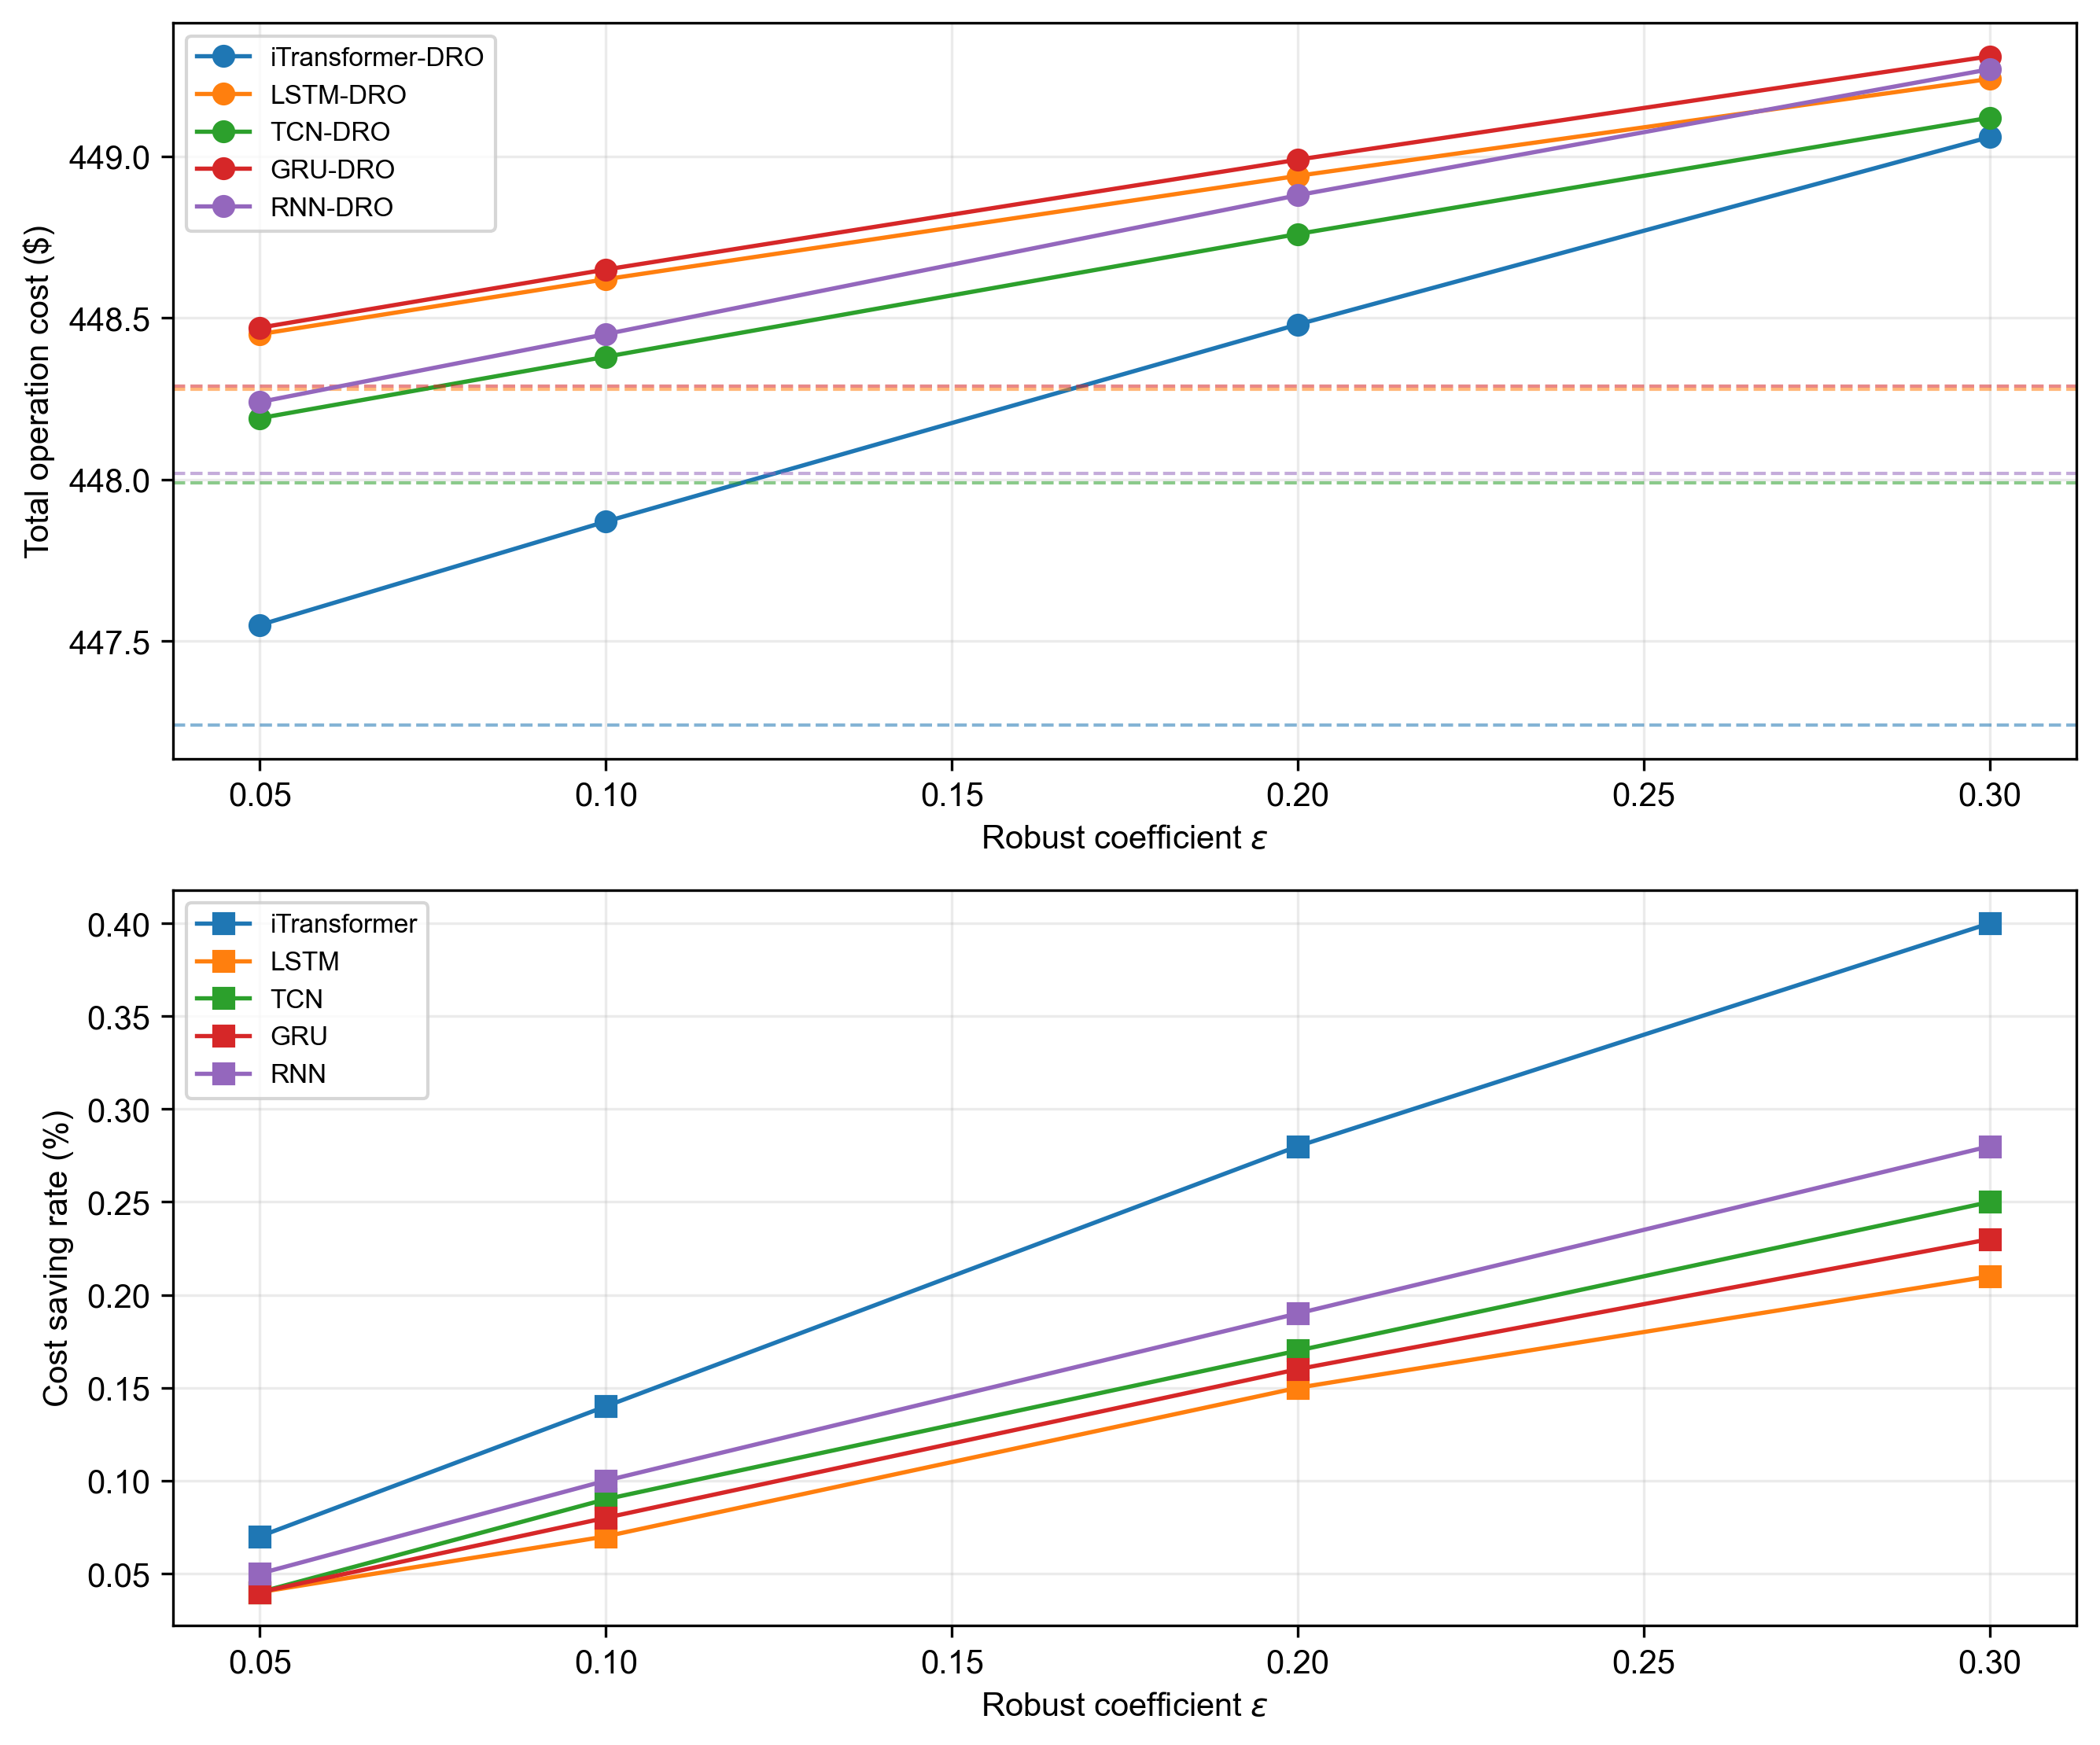

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 录入全部5模型数据
data = [
    ["iTransformer",0.05,447.24,447.55,0.07],
    ["iTransformer",0.10,447.24,447.87,0.14],
    ["iTransformer",0.20,447.24,448.48,0.28],
    ["iTransformer",0.30,447.24,449.06,0.40],
    ["LSTM",0.05,448.28,448.45,0.04],
    ["LSTM",0.10,448.28,448.62,0.07],
    ["LSTM",0.20,448.28,448.94,0.15],
    ["LSTM",0.30,448.28,449.24,0.21],
    ["TCN",0.05,447.99,448.19,0.04],
    ["TCN",0.10,447.99,448.38,0.09],
    ["TCN",0.20,447.99,448.76,0.17],
    ["TCN",0.30,447.99,449.12,0.25],
    ["GRU",0.05,448.29,448.47,0.04],
    ["GRU",0.10,448.29,448.65,0.08],
    ["GRU",0.20,448.29,448.99,0.16],
    ["GRU",0.30,448.29,449.31,0.23],
    ["RNN",0.05,448.02,448.24,0.05],
    ["RNN",0.10,448.02,448.45,0.10],
    ["RNN",0.20,448.02,448.88,0.19],
    ["RNN",0.30,448.02,449.27,0.28],
]
df = pd.DataFrame(data,columns=["Model","Eps","DMD_Cost","DRO_Cost","Save_Rate"])

models = ["iTransformer","LSTM","TCN","GRU","RNN"]
color_list = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]
eps_x = [0.05,0.1,0.2,0.3]

# 期刊绘图配置
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 10
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(9,7.5),dpi=300)

# 子图1：系统运行成本 DMD(虚线) / DRO(实线圆点)
for idx,name in enumerate(models):
    sub = df[df["Model"]==name]
    ax1.plot(sub["Eps"],sub["DRO_Cost"],marker="o",c=color_list[idx],lw=1.3,label=f"{name}-DRO")
    ax1.axhline(sub["DMD_Cost"].iloc[0],ls="--",c=color_list[idx],alpha=0.55,lw=1)
ax1.set_xlabel(r'Robust coefficient $\varepsilon$')
ax1.set_ylabel('Total operation cost ($)')
ax1.legend(loc="best",fontsize=8)
ax1.grid(alpha=0.25)

# 子图2：成本节约率（核心灵敏度）
for idx,name in enumerate(models):
    sub = df[df["Model"]==name]
    ax2.plot(sub["Eps"],sub["Save_Rate"],marker="s",c=color_list[idx],lw=1.3,label=name)
ax2.set_xlabel(r'Robust coefficient $\varepsilon$')
ax2.set_ylabel('Cost saving rate (%)')
ax2.legend(loc="best",fontsize=8)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("Sensitivity_Epsilon.tif",dpi=300,bbox_inches="tight")
plt.show()

✅ 图1 保存完成：Fig1_Scenario_Distribution.png
✅ 图2 保存完成：Fig2_Cost_Bar.png
✅ 图3 保存完成：Fig3_Wind_Boxplot.png
✅ 图4 保存完成：Fig4_Sensitivity_Curve.png

🎉 所有图表生成完毕！直接用于论文即可！


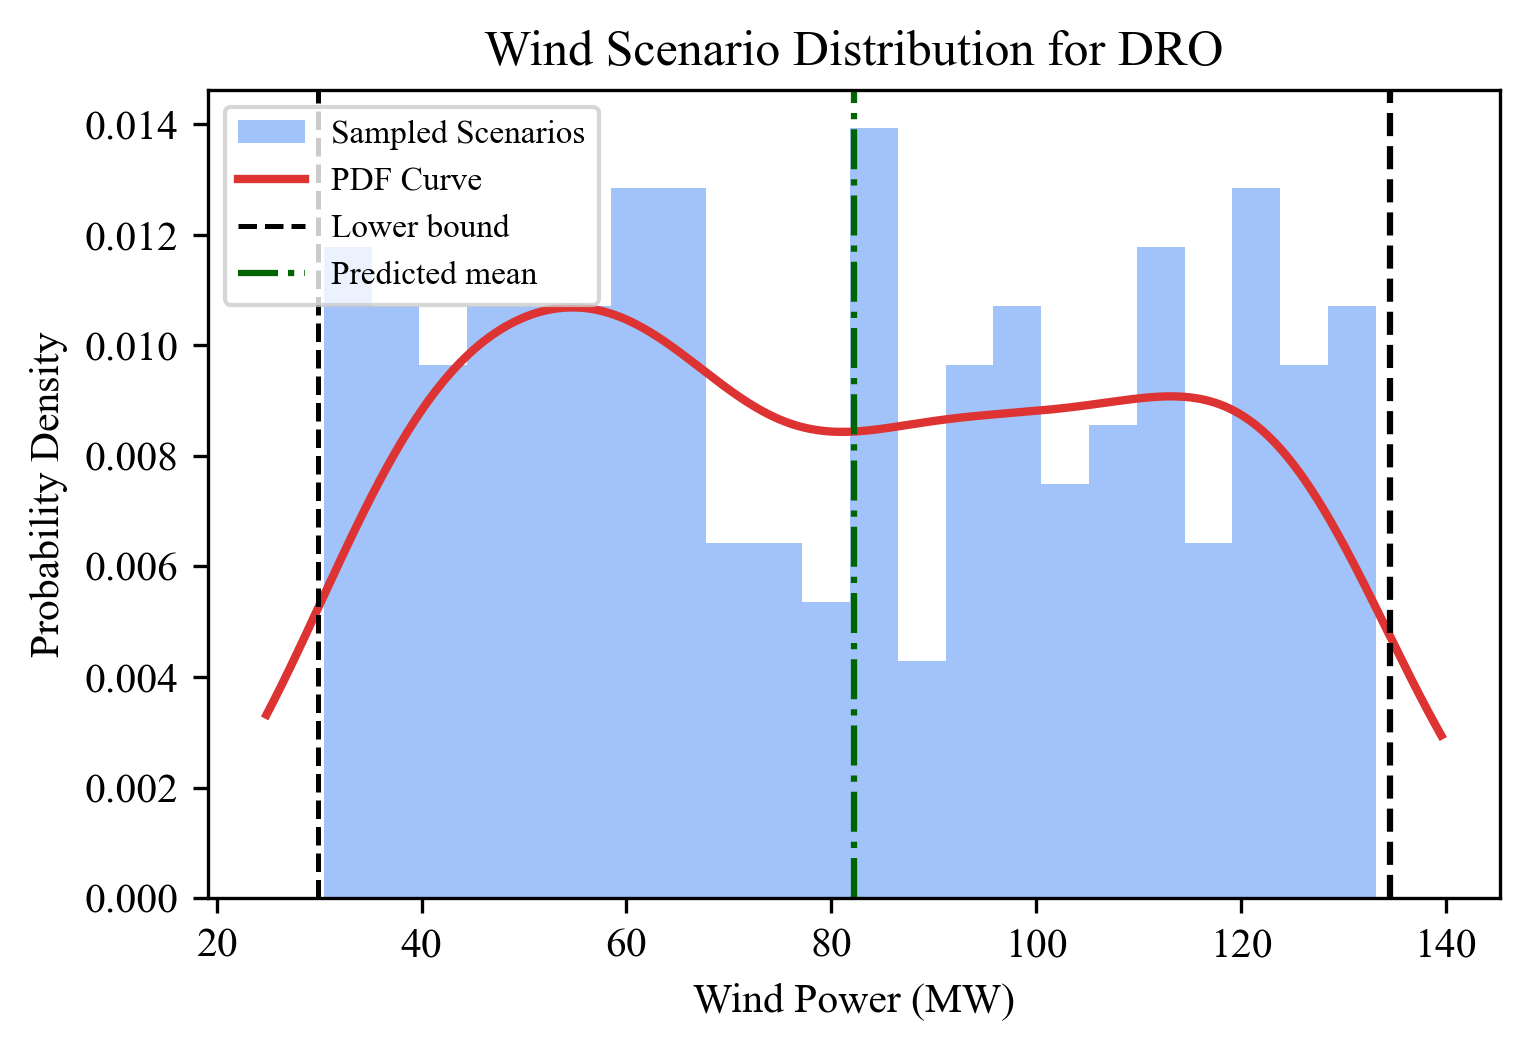

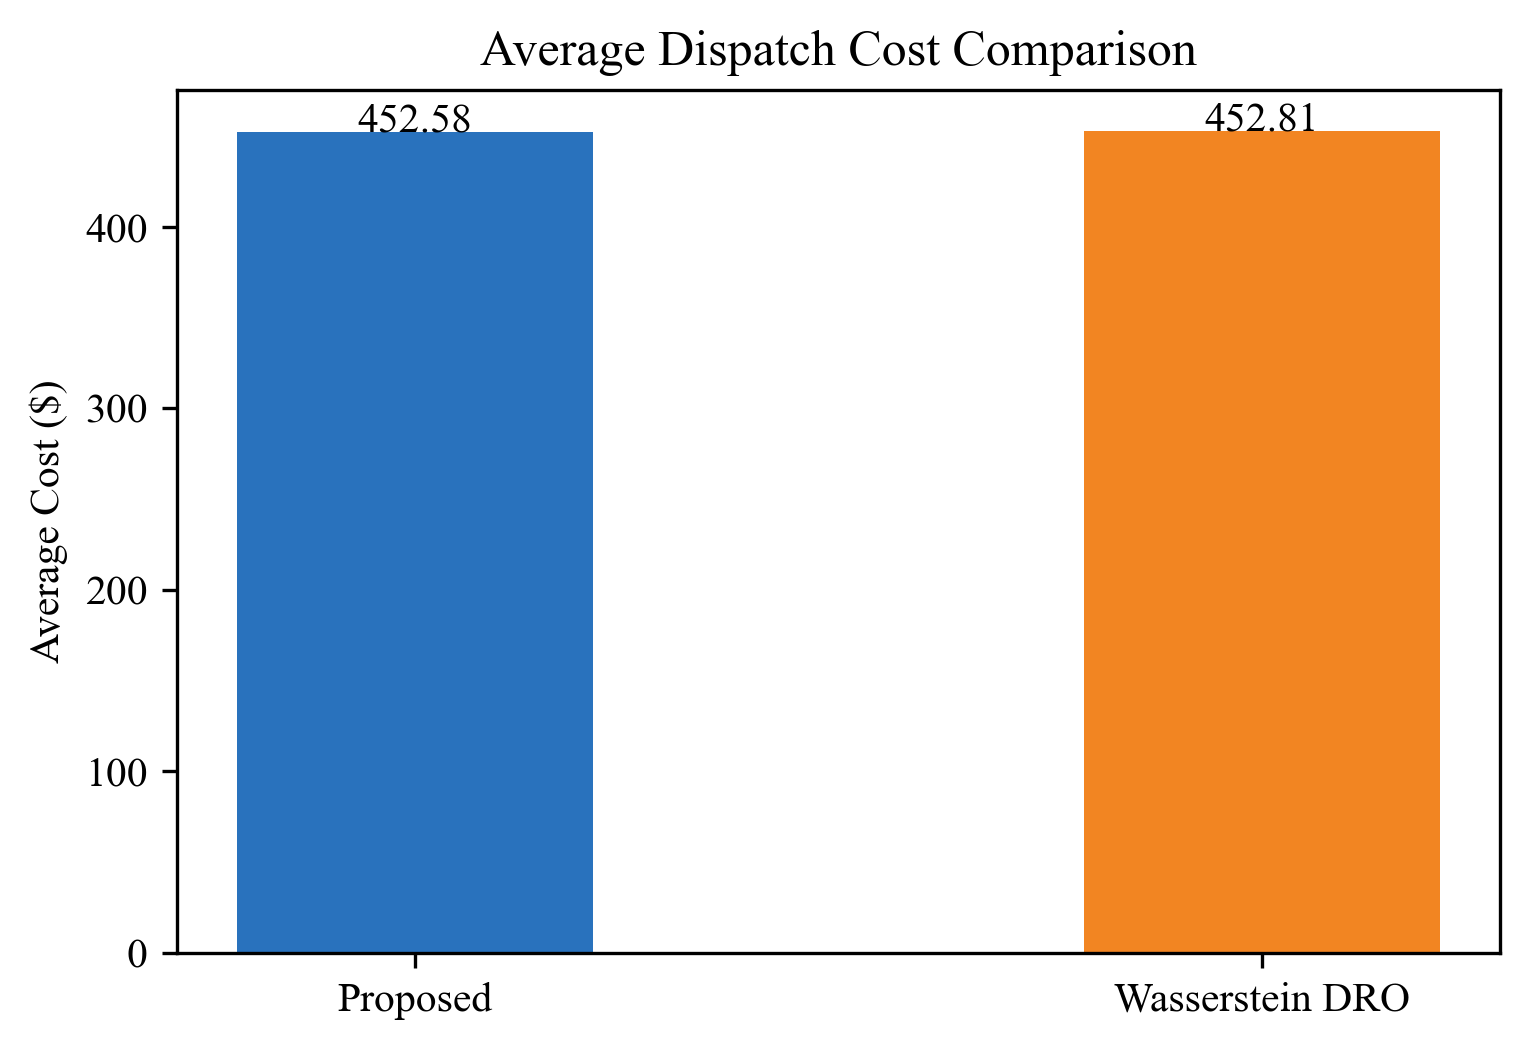

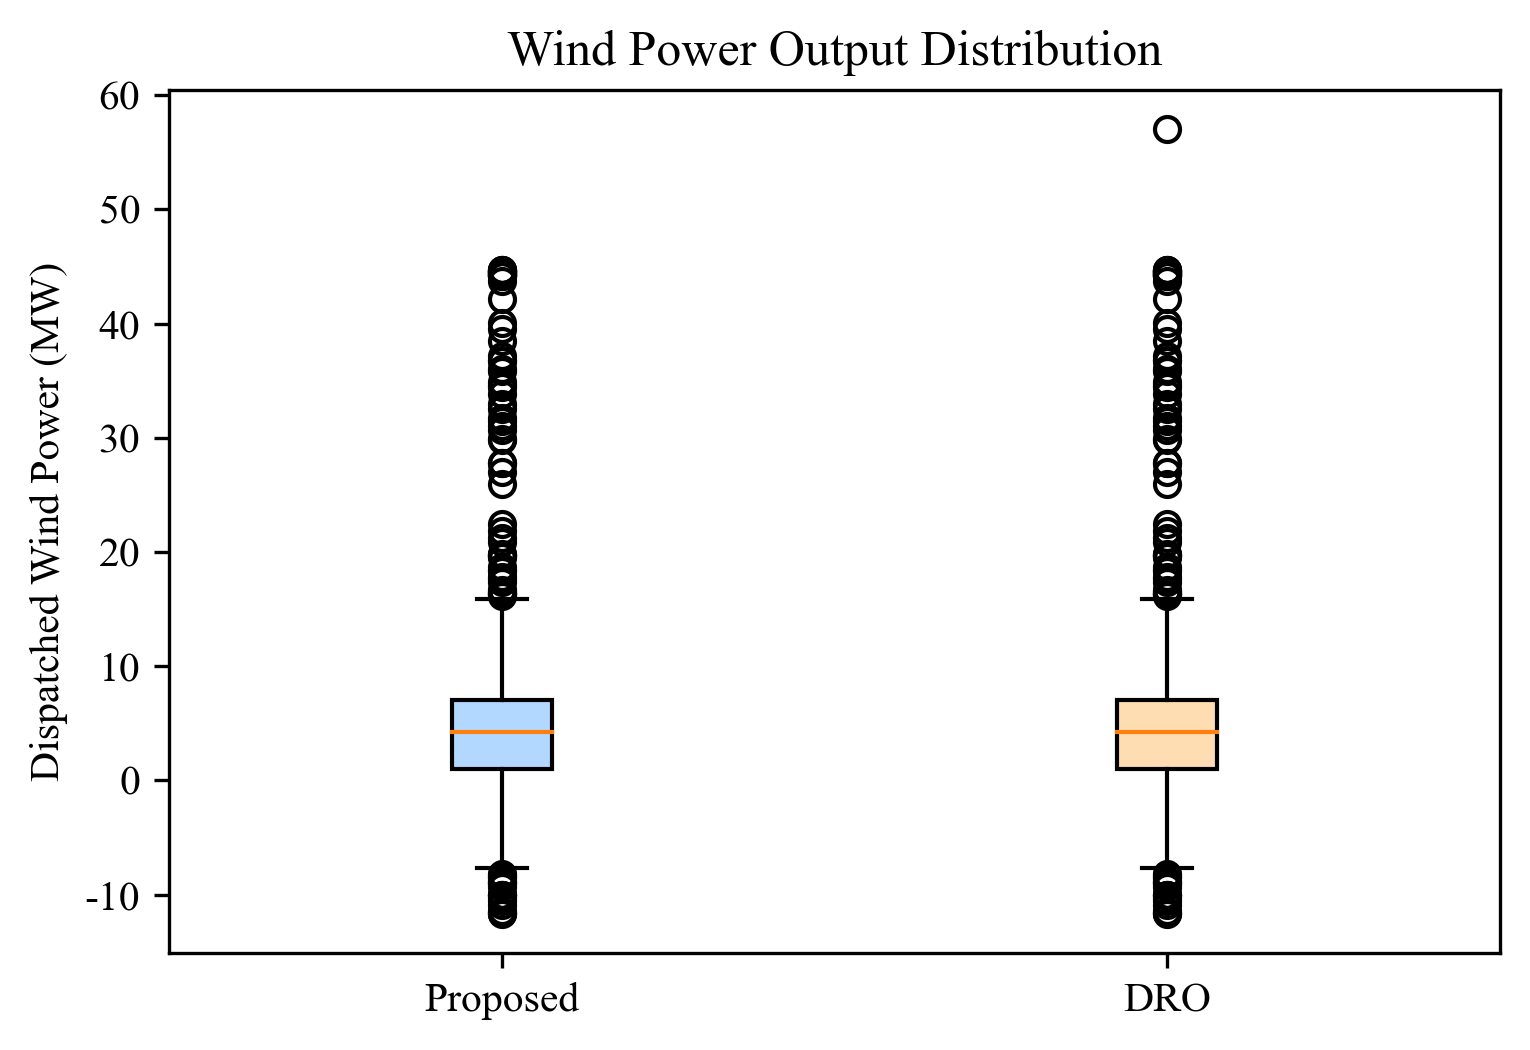

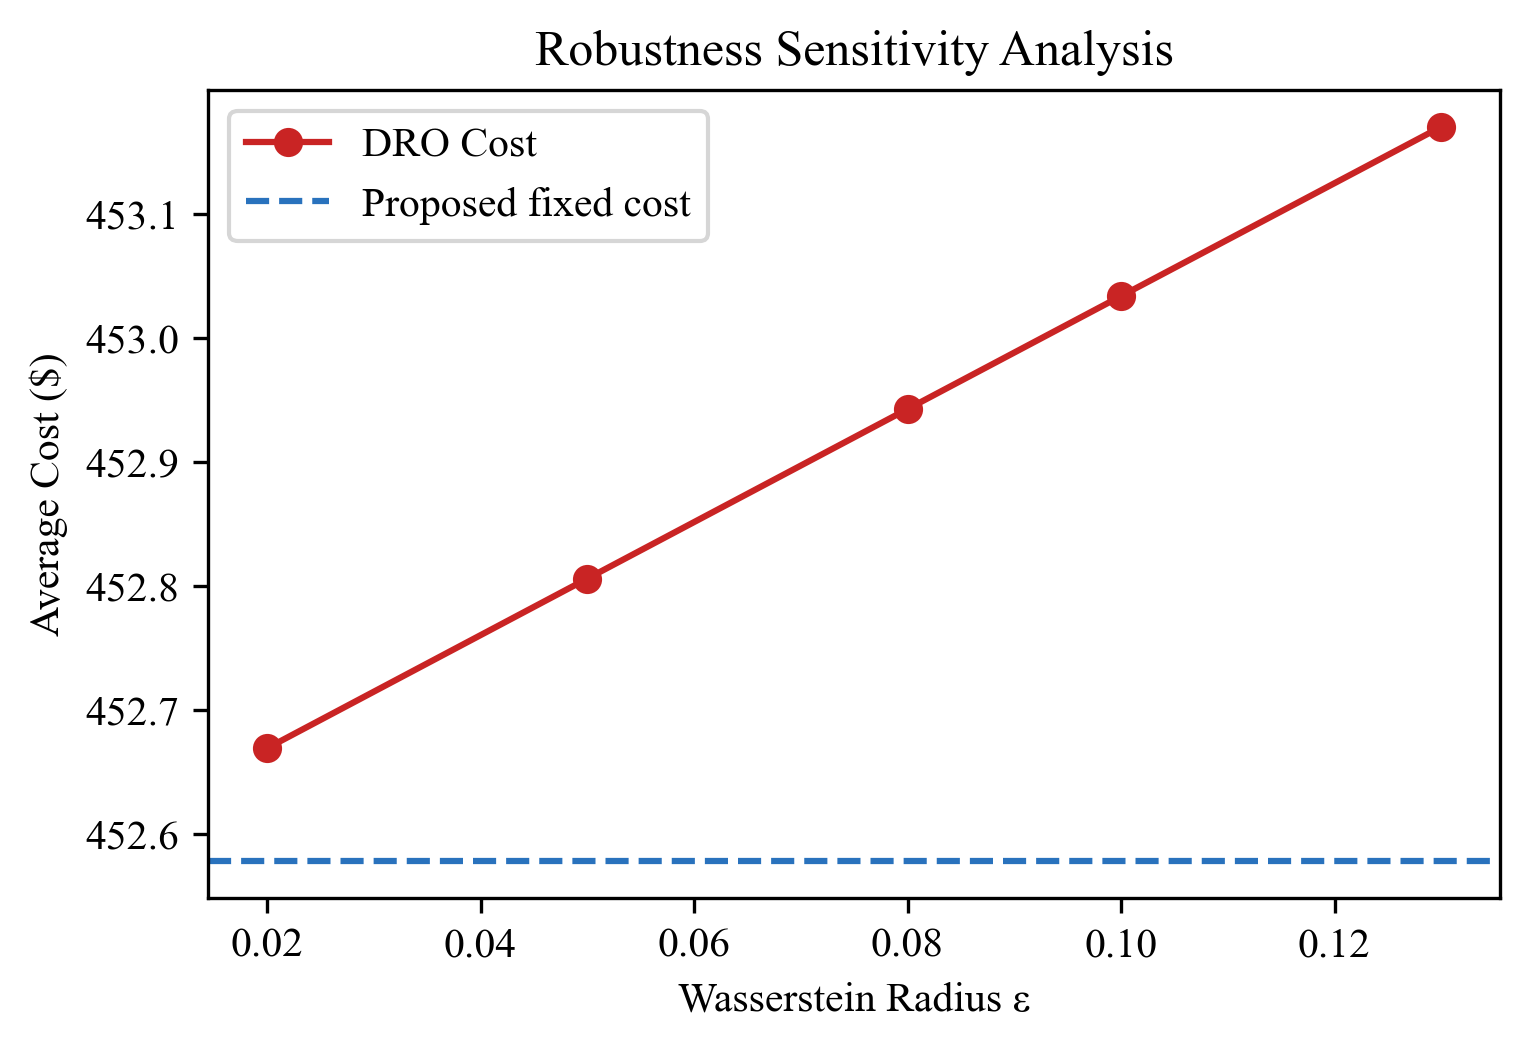

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ===================== 绘图样式设置 =====================
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300

# ===================== 图1：DRO 风电场景分布（你要的情景分布） =====================
row0 = dispatch_df.iloc[0]
wL = row0['itransformer_Lower_Bound']
wU = row0['itransformer_Upper_Bound']
np.random.seed(42)
sample_num = 200
wind_scene = np.random.uniform(wL, wU, sample_num)

plt.figure(figsize=(5.2, 3.6))
kde = gaussian_kde(wind_scene)
xx = np.linspace(wL - 5, wU + 5, 500)
plt.hist(wind_scene, bins=22, density=True, alpha=0.6, color='#639cf5', label='Sampled Scenarios')
plt.plot(xx, kde(xx), c='#dd3333', lw=2, label='PDF Curve')
plt.axvline(wL, c='k', ls='--', lw=1.2, label='Lower bound')
plt.axvline(wU, c='k', ls='--')
plt.axvline((wL + wU) / 2, c='darkgreen', ls='-.', label='Predicted mean')
plt.xlabel('Wind Power (MW)')
plt.ylabel('Probability Density')
plt.legend(fontsize=8)
plt.title('Wind Scenario Distribution for DRO')
plt.tight_layout()
plt.savefig('Fig1_Scenario_Distribution.png')
print("✅ 图1 保存完成：Fig1_Scenario_Distribution.png")

# ===================== 图2：平均成本柱状图 =====================
plt.figure(figsize=(5.2, 3.6))
avg_cost = [np.mean(cost_it), np.mean(cost_dro)]
plt.bar(['Proposed', 'Wasserstein DRO'], avg_cost, color=['#2972bd', '#f28522'], width=0.42)
for idx, val in enumerate(avg_cost):
    plt.text(idx, val + 0.1, f'{val:.2f}', ha='center')
plt.ylabel('Average Cost ($)')
plt.title('Average Dispatch Cost Comparison')
plt.tight_layout()
plt.savefig('Fig2_Cost_Bar.png')
print("✅ 图2 保存完成：Fig2_Cost_Bar.png")

# ===================== 图3：风电出力箱线图 =====================
plt.figure(figsize=(5.2, 3.6))
wind_data = [wind_it, wind_dro]
bp = plt.boxplot(wind_data, labels=['Proposed', 'DRO'], patch_artist=True)
for patch, col in zip(bp['boxes'], ['#b3d8ff', '#ffddb3']):
    patch.set_facecolor(col)
plt.ylabel('Dispatched Wind Power (MW)')
plt.title('Wind Power Output Distribution')
plt.tight_layout()
plt.savefig('Fig3_Wind_Boxplot.png')
print("✅ 图3 保存完成：Fig3_Wind_Boxplot.png")

# ===================== 图4：鲁棒半径敏感性曲线 =====================
eps_list = [0.02, 0.05, 0.08, 0.1, 0.13]
eps_cost = []
for eps in eps_list:
    tmp = []
    for _, r in dispatch_df.iterrows():
        c, _ = run_dro(r, eps)
        tmp.append(c)
    eps_cost.append(np.mean(tmp))

plt.figure(figsize=(5.2, 3.6))
plt.plot(eps_list, eps_cost, 'o-', c='#c92424', label='DRO Cost')
plt.axhline(np.mean(cost_it), ls='--', c='#2972bd', label='Proposed fixed cost')
plt.xlabel('Wasserstein Radius ε')
plt.ylabel('Average Cost ($)')
plt.legend()
plt.title('Robustness Sensitivity Analysis')
plt.tight_layout()
plt.savefig('Fig4_Sensitivity_Curve.png')
print("✅ 图4 保存完成：Fig4_Sensitivity_Curve.png")

print("\n🎉 所有图表生成完毕！直接用于论文即可！")